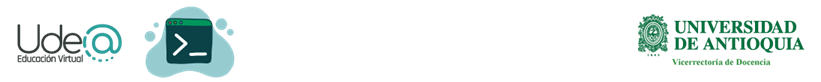

# <h1><center>KERNEL PCA</center></h1>

**Especialización en Analítica de Datos**

*Prof. Hernán Felipe García Arias*

*Facultad de Ingeniería*

*Universidad de Antioquia*


**2025-1**



# Kernel PCA

This example shows the difference between the Principal Components Analysis
(:class:`~sklearn.decomposition.PCA`) and its kernalized version
(:class:`~sklearn.decomposition.KernelPCA`).

On the one hand, we show that :class:`~sklearn.decomposition.KernelPCA` is able
to find a projection of the data which linearly separates them while it is not the case
with :class:`~sklearn.decomposition.PCA`.

Finally, we show that inverting this projection is an approximation with
:class:`~sklearn.decomposition.KernelPCA`, while it is exact with
:class:`~sklearn.decomposition.PCA`.

*Thanks to SKLEARN*


## Projecting data: `PCA` vs. `KernelPCA`

In this section, we show the advantages of using a kernel when
projecting data using a Principal Component Analysis (PCA). We create a
dataset made of two nested circles.



In [ ]:
from sklearn.datasets import make_circles
from sklearn.model_selection import train_test_split

X, y = make_circles(n_samples=1000, factor=0.3, noise=0.05, random_state=0)
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0, test_size=0.3)

Let's have a quick first look at the generated dataset.



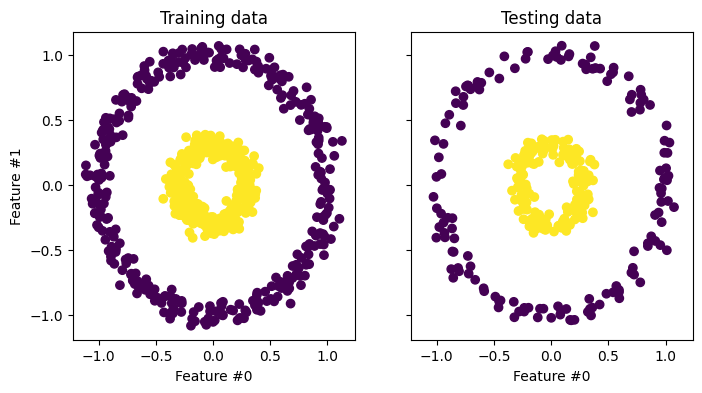

In [ ]:
import matplotlib.pyplot as plt

_, (train_ax, test_ax) = plt.subplots(ncols=2, sharex=True, sharey=True, figsize=(8, 4))

train_ax.scatter(X_train[:, 0], X_train[:, 1], c=y_train)
train_ax.set_ylabel("Feature #1")
train_ax.set_xlabel("Feature #0")
train_ax.set_title("Training data")

test_ax.scatter(X_test[:, 0], X_test[:, 1], c=y_test)
test_ax.set_xlabel("Feature #0")
_ = test_ax.set_title("Testing data")

The samples from each class cannot be linearly separated: there is no
straight line that can split the samples of the inner set from the outer
set.

Now, we will use PCA with and without a kernel to see what is the effect of
using such a kernel. The kernel used here is a radial basis function (RBF)
kernel.



In [ ]:
from sklearn.decomposition import PCA, KernelPCA

pca = PCA(n_components=2)
kernel_pca = KernelPCA(
    n_components=None, kernel="rbf", gamma=10, alpha=0.1
)

pca.fit(X_train)
X_test_pca = pca.transform(X_test) # Primero ajusta con Xtrain y transforma a Xtest
X_test_kernel_pca = kernel_pca.fit(X_train).transform(X_test)

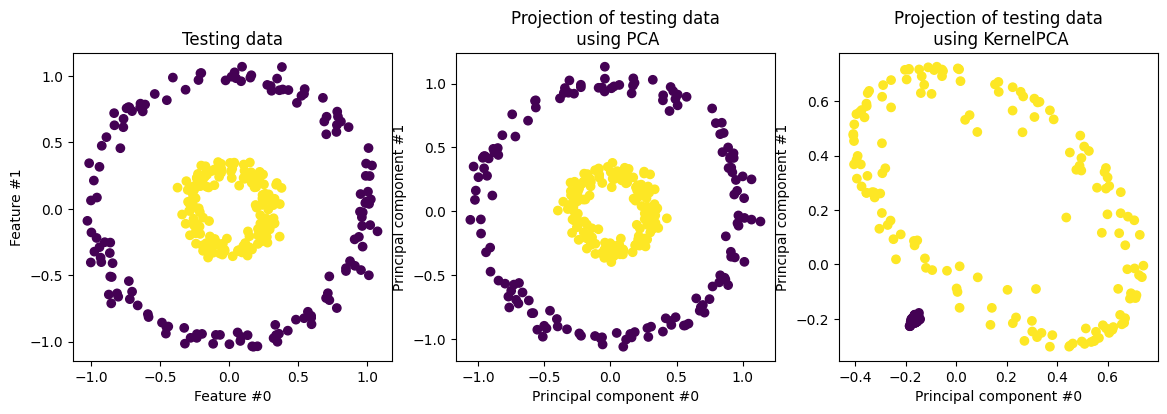

In [ ]:
fig, (orig_data_ax, pca_proj_ax, kernel_pca_proj_ax) = plt.subplots(
    ncols=3, figsize=(14, 4)
)

orig_data_ax.scatter(X_test[:, 0], X_test[:, 1], c=y_test)
orig_data_ax.set_ylabel("Feature #1")
orig_data_ax.set_xlabel("Feature #0")
orig_data_ax.set_title("Testing data")

pca_proj_ax.scatter(X_test_pca[:, 0], X_test_pca[:, 1], c=y_test)
pca_proj_ax.set_ylabel("Principal component #1")
pca_proj_ax.set_xlabel("Principal component #0")
pca_proj_ax.set_title("Projection of testing data\n using PCA")

kernel_pca_proj_ax.scatter(X_test_kernel_pca[:, 0], X_test_kernel_pca[:, 1], c=y_test)
kernel_pca_proj_ax.set_ylabel("Principal component #1")
kernel_pca_proj_ax.set_xlabel("Principal component #0")
_ = kernel_pca_proj_ax.set_title("Projection of testing data\n using KernelPCA")

We recall that PCA transforms the data linearly. Intuitively, it means that
the coordinate system will be centered, rescaled on each component
with respected to its variance and finally be rotated.
The obtained data from this transformation is isotropic and can now be
projected on its _principal components_.

Thus, looking at the projection made using PCA (i.e. the middle figure), we
see that there is no change regarding the scaling; indeed the data being two
concentric circles centered in zero, the original data is already isotropic.
However, we can see that the data have been rotated. As a
conclusion, we see that such a projection would not help if define a linear
classifier to distinguish samples from both classes.

Using a kernel allows to make a non-linear projection. Here, by using an RBF
kernel, we expect that the projection will unfold the dataset while keeping
approximately preserving the relative distances of pairs of data points that
are close to one another in the original space.

We observe such behaviour in the figure on the right: the samples of a given
class are closer to each other than the samples from the opposite class,
untangling both sample sets. Now, we can use a linear classifier to separate
the samples from the two classes.



Ahora probemos el desempeño de un sistema de clasificación


Utilizaremos un sistema que se conoce como el Clasificador Bayesiano.

Acc(%):  1.0


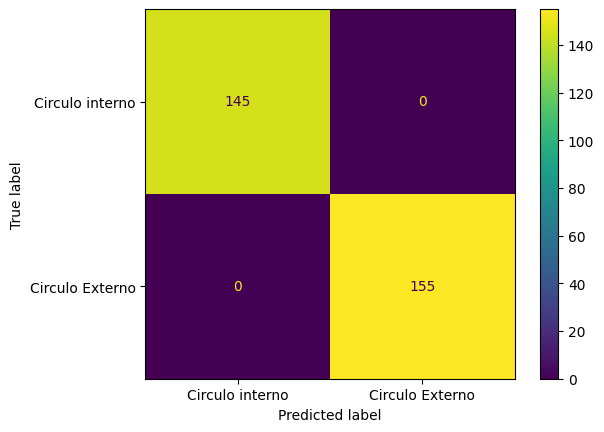

In [ ]:
from sklearn.naive_bayes import GaussianNB
import numpy as np

# Instanciamos nuestro modelo Bayesiano
clasificadorBayes = GaussianNB()
clasificadorBayes.fit(X_train,y_train)

# Realizar una prediccion
y_pred = clasificadorBayes.predict(X_test)
# Realizamo el análisis del erro
error = np.sum(np.abs(y_pred-y_test))
Acierto = 1.- error/len(y_test)
# Analizar algo que se conoce como una matriz de confusión
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

CMAT = confusion_matrix(y_test,y_pred)
porcentajeAcierto = np.sum(np.diag(CMAT)) / len(y_test)
print('Acc(%): ',porcentajeAcierto)
ax = ConfusionMatrixDisplay(CMAT,display_labels=['Circulo interno','Circulo Externo'])
ax.plot()
plt.show()

### PCA for Hand-written digits Recognition



In [ ]:
from sklearn.datasets import load_digits
digits = load_digits()
N, D = digits.data.shape
print('# Observations: ', N,'\t# Features: ',D)

# Observations:  1797 	# Features:  64


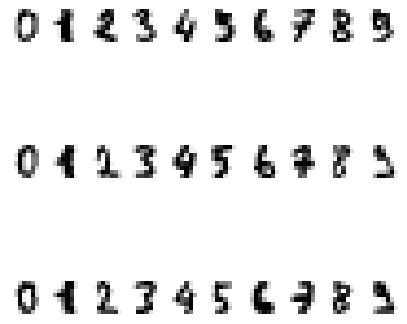

In [ ]:
#Display the first ten digits
fig, axs = plt.subplots(3,10, figsize=(5, 5), facecolor='w', edgecolor='k')
axs = axs.ravel()
for nDigit in range(30):
  digitImg = digits.images[nDigit]
  axs[nDigit].imshow(digitImg, cmap=plt.cm.gray_r, interpolation='nearest')
  axs[nDigit].axis('off')
plt.show()

Recall that the data consists of 8×8 pixel images, meaning that they are 64-dimensional.
To gain some intuition into the relationships between these points, we can use PCA to project them to a more manageable number of dimensions, say two:

In [ ]:
kernel_pca = KernelPCA(
    n_components=2, kernel="rbf")
# Load our dataset X
X = digits.data
projectedZ = kernel_pca.fit_transform(X)
BasisW = kernel_pca.eigenvectors_
print('Input Space:',digits.data.shape)
print('Latent Space:',projectedZ.shape)
print(kernel_pca.eigenvalues_)
print(BasisW.shape)

Input Space: (1797, 64)
Latent Space: (1797, 2)
[2.34815573 1.96697407]
(1797, 2)


<ipython-input-28-d9e4ba29bde7>:3: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap=plt.cm.get_cmap('tab10', 10))


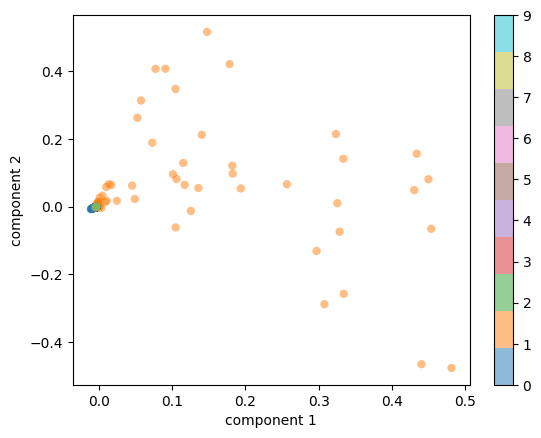

In [ ]:
plt.scatter(projectedZ[:, 0], projectedZ[:, 1],
             c=digits.target, edgecolor='none', alpha=0.5,
            cmap=plt.cm.get_cmap('tab10', 10))
plt.xlabel('component 1')
plt.ylabel('component 2')
plt.colorbar();

Ahora realicemos el reconocimiento de los dígitos utilizando un clasificador Bayesiano

In [ ]:
from sklearn.naive_bayes import GaussianNB
import numpy as np
#Flag_Space = 'Latent'

from ipywidgets import interact

@interact(Flag_Space = ['Latent','Input'])

def ExperimentoBayes(Flag_Space):
  if Flag_Space == 'Input':
    X = digits.data
    y = digits.target
    X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0, test_size=0.3)

  if Flag_Space == 'Latent':
    X = projectedZ
    y = digits.target
    X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0, test_size=0.3)

  # Instanciamos nuestro modelo Bayesiano
  clasificadorBayes = GaussianNB()
  clasificadorBayes.fit(X_train,y_train)

  # Realizar una prediccion
  y_pred = clasificadorBayes.predict(X_test)
  # Realizamo el análisis del erro
  error = np.sum(np.abs(y_pred-y_test))
  Acierto = 1.- error/len(y_test)
  # Analizar algo que se conoce como una matriz de confusión
  from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

  CMAT = confusion_matrix(y_test,y_pred)
  porcentajeAcierto = np.sum(np.diag(CMAT)) / len(y_test)
  print('Acc(%): ',porcentajeAcierto)
  ax = ConfusionMatrixDisplay(CMAT,display_labels=['0','1','2','3','4','5','6','7','8','9'])
  ax.plot()
  plt.show()

interactive(children=(Dropdown(description='Flag_Space', options=('Latent', 'Input'), value='Latent'), Output(…